In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# start 8:14pm

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [4]:
question = 'what has been seen in the last six hours?'

answer = ask_api(client, question)
len(answer)

893

In [5]:
answer[0]

{'claim': 'Alice Greco, president of Uildm Bologna, has died at 36 after fighting for the rights of people with disabilities.',
 'url': 'https://corrieredibologna.corriere.it/notizie/cronaca/26_marzo_21/alice-greco-morta-a-36-anni-la-presidente-della-uildm-di-bologna-ha-lottato-per-i-diritti-delle-persone-con-disabilita-743587c7-0a45-47c7-a97f-0bd6f4beaxlk.shtml',
 'domain': 'corrieredibologna.corriere.it',
 'url_domain': 'corrieredibologna.corriere.it',
 'date_added': '2026-03-21 16:59:26'}

In [6]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

,claim,url,domain,url_domain,date_added
0,"Alice Greco, president of Uildm Bologna, has d...",https://corrieredibologna.corriere.it/notizie/...,corrieredibologna.corriere.it,corrieredibologna.corriere.it,2026-03-21 09:59:26-07:00
1,An Indian-origin Telugu man named Nagaraju Bal...,https://www.hindustantimes.com/world-news/us-n...,hindustantimes.com,hindustantimes.com,2026-03-21 09:59:11-07:00
2,A high school diploma was delivered to Alvaro ...,https://abc7chicago.com/post/nassau-county-ny-...,abc7chicago.com,abc7chicago.com,2026-03-21 09:57:27-07:00
3,Notre Dame will cover tuition for families ear...,https://14news.com/2026/03/20/notre-dame-cover...,14news.com,14news.com,2026-03-21 09:57:27-07:00
4,Discussion on parents refusing vaccines affect...,https://www.nbcchicago.com/news/national-inter...,nbcchicago.com,nbcchicago.com,2026-03-21 09:55:34-07:00


In [7]:
df.to_csv('claim_edgelist.csv', header=True, index=False)

In [8]:
df.tail() # six hours

,claim,url,domain,url_domain,date_added
888,Local news article discussing water quality is...,https://record-eagle.com/news/local_news/trave...,record-eagle.com,record-eagle.com,2026-03-21 04:02:27-07:00
889,Event listing for a concert featuring The Isla...,https://www.eventbrite.com.au/e/the-island-sun...,eventbrite.com.mx/d/australia--sydney/events,eventbrite.com.au,2026-03-21 04:02:21-07:00
890,Dear Abby column addressing a mother's dilemma...,https://chicago.suntimes.com/dear-abby/2026/03...,chicago.suntimes.com,chicago.suntimes.com,2026-03-21 04:02:17-07:00
891,Photography piece on honoring a fallen firefig...,https://chicago.suntimes.com/photography/2026/...,chicago.suntimes.com,chicago.suntimes.com,2026-03-21 04:02:17-07:00
892,"A shooting incident in River North, Chicago, i...",https://abc7chicago.com/post/river-north-chica...,abc7chicago.com,abc7chicago.com,2026-03-21 03:59:46-07:00


In [9]:
df.shape

(893, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [10]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [11]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [12]:
df.head()

,claim,url,domain,url_domain,date_added
0,"Alice Greco, president of Uildm Bologna, has d...",https://corrieredibologna.corriere.it/notizie/...,corrieredibologna.corriere.it,corrieredibologna.corriere.it,2026-03-21 09:59:26-07:00
1,An Indian-origin Telugu man named Nagaraju Bal...,https://www.hindustantimes.com/world-news/us-n...,hindustantimes.com,hindustantimes.com,2026-03-21 09:59:11-07:00
2,A high school diploma was delivered to Alvaro ...,https://abc7chicago.com/post/nassau-county-ny-...,abc7chicago.com,abc7chicago.com,2026-03-21 09:57:27-07:00
3,Notre Dame will cover tuition for families ear...,https://14news.com/2026/03/20/notre-dame-cover...,14news.com,14news.com,2026-03-21 09:57:27-07:00
4,Discussion on parents refusing vaccines affect...,https://www.nbcchicago.com/news/national-inter...,nbcchicago.com,nbcchicago.com,2026-03-21 09:55:34-07:00


In [13]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,"Alice Greco, president of Uildm Bologna, has d...",https://corrieredibologna.corriere.it/notizie/...,corrieredibologna.corriere.it,corrieredibologna.corriere.it,2026-03-21 09:59:26-07:00,0
1,An Indian-origin Telugu man named Nagaraju Bal...,https://www.hindustantimes.com/world-news/us-n...,hindustantimes.com,hindustantimes.com,2026-03-21 09:59:11-07:00,1
2,A high school diploma was delivered to Alvaro ...,https://abc7chicago.com/post/nassau-county-ny-...,abc7chicago.com,abc7chicago.com,2026-03-21 09:57:27-07:00,2
3,Notre Dame will cover tuition for families ear...,https://14news.com/2026/03/20/notre-dame-cover...,14news.com,14news.com,2026-03-21 09:57:27-07:00,3
4,Discussion on parents refusing vaccines affect...,https://www.nbcchicago.com/news/national-inter...,nbcchicago.com,nbcchicago.com,2026-03-21 09:55:34-07:00,4


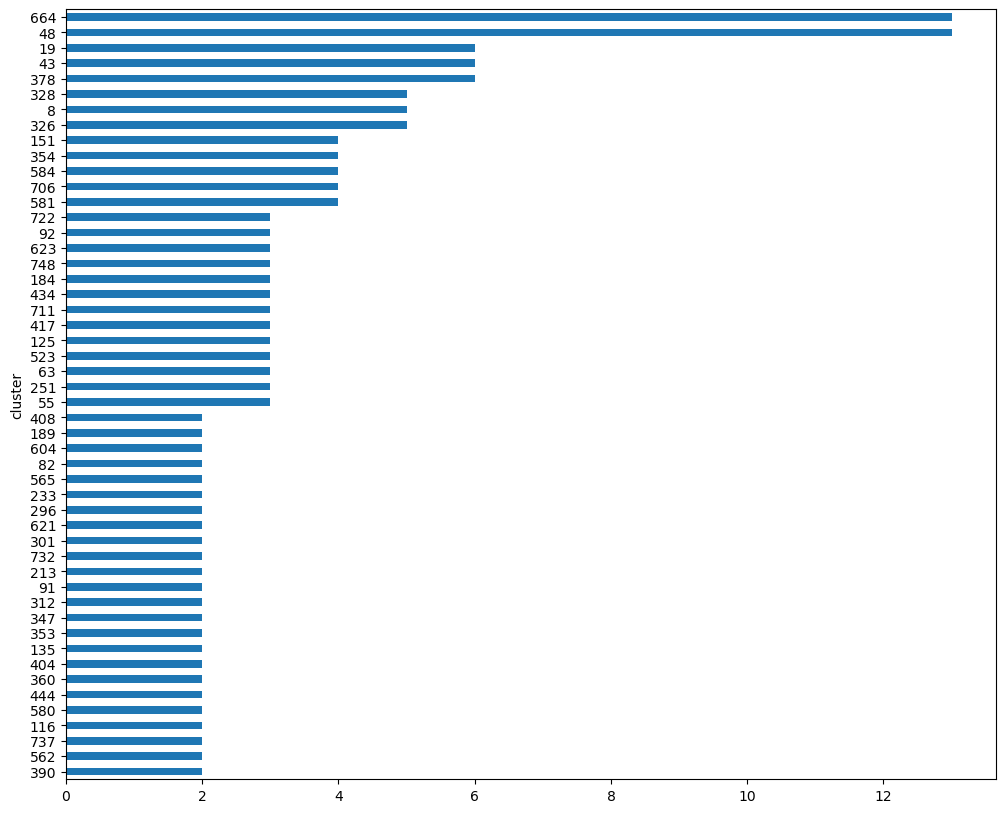

In [14]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [15]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([664,  48,  19,  43, 378, 328,   8, 326, 151, 354, 584, 706, 581,
       722,  92, 623, 748, 184, 434, 711, 417, 125, 523,  63, 251,  55,
       408, 189, 604,  82, 565, 233, 296, 621, 301, 732, 213,  91, 312,
       347, 353, 135, 404, 360, 444, 580, 116, 737, 562, 390, 208, 137,
        95, 149, 533, 393, 266, 518, 272, 558, 238, 278, 293, 504, 406,
       499, 361, 220, 247, 261,  59, 698,   5, 300, 609, 608, 597, 596,
       655, 598, 610, 611, 654, 663, 607, 599, 656, 661, 605, 603, 657,
       612, 662, 602, 601, 658, 600, 659, 606, 651, 653, 640, 641, 626,
       627, 629, 630, 631, 632, 652, 633, 634, 635, 639, 638, 636, 642,
       622, 620, 644, 645, 646, 647, 648, 649, 619, 650, 618, 616, 615,
       614, 613, 637,   0, 574, 594, 519, 506, 507, 509, 510, 511, 512,
       513, 514, 525, 502, 526, 528, 529, 530, 531, 532, 534, 535, 503,
       501, 593, 489, 479, 481, 482, 483, 484, 486, 487, 488, 490, 500,
       491, 492, 493, 494, 495, 496, 497, 498, 536, 537, 538, 57

In [16]:
for cluster in top_clusters:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 664
['A news article reporting on a specific topic or event.'
 'News article or report' 'News article or report'
 'News article or report' 'News article or report'
 'News article related to an unspecified topic'
 'Local news article related to a current event.'
 'News article or update related to an event or topic'
 'News article or update related to an event or topic'
 'News article or update related to an event or topic'
 'News article with potential information or stories related to a specific event or topic.'
 'News article or report on a specific topic'
 'News article or report on a specific topic']

cluster: 48
['Hawaii is experiencing its worst flooding in 20 years.'
 'Hawaii is experiencing its worst flooding in 20 years, which threatens a dam and has prompted evacuations.'
 'Hawaii is experiencing its worst flooding in 20 years, prompting evacuations and threatening a dam.'
 'Hawaii is experiencing its worst flooding in 20 years and more rain is on the way.'
 'Hawaii 

['A review or announcement about a sweet story presented by the Baker City theater troupe.']

cluster: 549
['Claims regarding a specific issue discussed in the article.']

cluster: 550
['Claims related to another issue or topic mentioned.']

cluster: 551
['Claims about an event or situation described in the content.']

cluster: 552
['Claims pertaining to findings or conclusions drawn in the article.']

cluster: 553
['The safety of downloads is being challenged, indicating a deceptive perception of online security.']

cluster: 554
['A federal court has rejected changes to childhood vaccine schedules, describing it as an overreach of judicial power.']

cluster: 555
['New Jersey and Roxbury Township are suing the Trump administration regarding the establishment of an immigration detention facility.']

cluster: 556
['A Carlisle man has been fired upon by police using a handgun.']

cluster: 557
['An event for the IDS Annual Lecture 2026 featuring Jason Hickel.']

cluster: 666
['Event announ

['The Bachelorette season 22 has been cancelled.']

cluster: 158
['A beloved Auburn graduate was killed in a shooting and is remembered for her positive qualities.']

cluster: 159
['Shots were fired during a meetup in Birmingham, resulting in one death and one injury.']

cluster: 160
["A car manufacturer recalled over 61,000 SUVs following a child's tragic death."]

cluster: 161
["There's a discussion about a new tradition replacing the Alabama Butterbean Festival due to feelings of shame and betrayal."]

cluster: 162
['Alabama may reform its approach to handling threats in schools and public spaces.']

cluster: 163
['A 15-year-old is among three teens taken into custody after a double shooting.']

cluster: 164
['A high school coach has experienced significant spiritual moments during a health scare.']

cluster: 165
['A woman was arrested after her toddler niece died from a drug overdose.']

cluster: 145
['This season of The Bachelorette was cancelled due to a domestic abuse scandal in

['Announcement of an Easter party for dogs in Dallas']

cluster: 439
['Announcement of an event related to the show Twin Peaks in Dallas']

cluster: 441
['A Palestinian man alleges he was sexually assaulted by Israeli settlers in front of his family']

cluster: 452
['There was an incident of abuse involving a school bus aide.']

cluster: 442
['Event details for comedian David Spade']

cluster: 443
['Event details for Studio 361']

cluster: 445
['Event for Mild Universe featuring Theodor']

cluster: 446
['Live music event at the Troubadour']

cluster: 447
['Event about Texas trees in Dallas']

cluster: 448
['Easter brunch event in Dallas at the Pyramid Restaurant']

cluster: 1
['An Indian-origin Telugu man named Nagaraju Balkam was arrested in a child predator sting operation in Santa Fe, and the bodycam video of the event has gone viral.']

cluster: 451
['There is a meningitis outbreak in Kent with 34 reported cases.']

cluster: 365
['A blast at an explosives factory in Babina has resu

In [17]:
# end 8:15pm